In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
stats_df = pd.read_csv("../statistics.csv")

stats_df = stats_df[["match_id", "period", "statistic_name", "home_value", "away_value"]].copy()

In [3]:
breaks_df = stats_df[
    stats_df["statistic_name"] == "break_points_converted"].copy()

print(f" Rows with break_points_converted: {len(breaks_df):,}")

 Rows with break_points_converted: 76,265


In [4]:
breaks_df = breaks_df[breaks_df["period"] == "ALL"]
print(f" Rows after keeping period == ALL: {len(breaks_df):,}")

breaks_df = breaks_df.dropna(subset=["match_id", "home_value", "away_value"])

 Rows after keeping period == ALL: 23,291


In [5]:
before = len(breaks_df)
breaks_df = breaks_df[
    (breaks_df["home_value"] >= 0) &
    (breaks_df["away_value"] >= 0)]

print(f" Dropped {before - len(breaks_df):,} rows with negative values")

 Dropped 0 rows with negative values


In [6]:
before = len(breaks_df)
breaks_df = breaks_df.drop_duplicates(subset=["match_id", "period", "statistic_name"])
print(f" Dropped {before - len(breaks_df):,} duplicate rows")

breaks_df["total_breaks"] = breaks_df["home_value"] + breaks_df["away_value"]

 Dropped 11,898 duplicate rows


In [7]:
avg_breaks  = breaks_df["total_breaks"].mean().round(3)
med_breaks  = breaks_df["total_breaks"].median()
std_breaks  = breaks_df["total_breaks"].std().round(3)
total_matches = len(breaks_df)

print(f"\nTotal matches used in calculation: {total_matches:,}")
print(f"Matches with 0 breaks: "
      f"{(breaks_df['total_breaks'] == 0).sum():,}")

print("\n" + "-" * 45)
print("  Average Breaks of Serve per Match")
print("-" * 45)
print(f"  Mean   : {avg_breaks}")
print(f"  Median : {med_breaks}")
print(f"  Std Dev: {std_breaks}")
print(f"  Total Matches: {total_matches:,}")


Total matches used in calculation: 11,393
Matches with 0 breaks: 308

---------------------------------------------
  Average Breaks of Serve per Match
---------------------------------------------
  Mean   : 6.446
  Median : 6.0
  Std Dev: 3.313
  Total Matches: 11,393


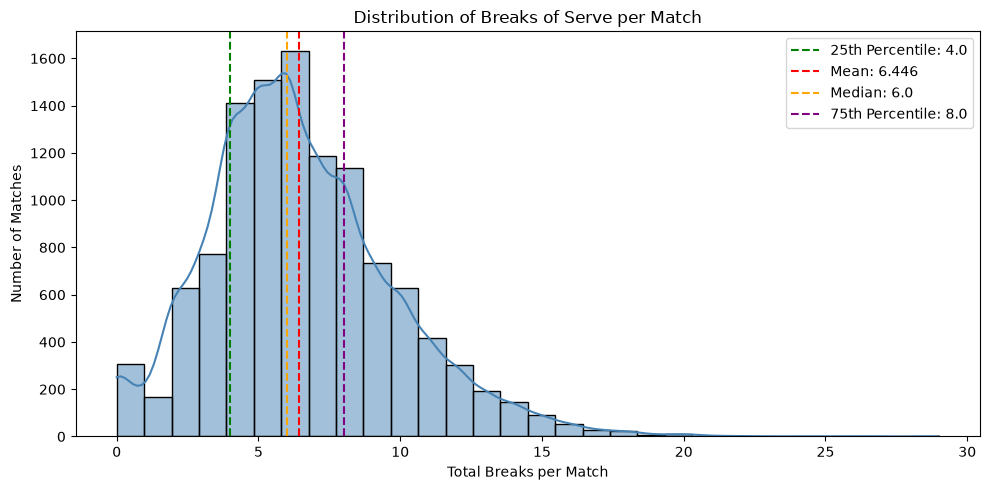

In [14]:

fig, ax = plt.subplots(figsize=(10, 5))

q25 = breaks_df["total_breaks"].quantile(0.25)
q75 = breaks_df["total_breaks"].quantile(0.75)

sns.histplot(breaks_df["total_breaks"], bins=30, kde=True, color="steelblue", ax=ax)

ax.axvline(q25, color="green", linestyle="--", label=f"25th Percentile: {q25}")
ax.axvline(avg_breaks, color="red",    linestyle="--", label=f"Mean: {avg_breaks}")
ax.axvline(med_breaks, color="orange", linestyle="--", label=f"Median: {med_breaks}")
ax.axvline(q75, color="purple", linestyle="--", label=f"75th Percentile: {q75}")

ax.set_title("Distribution of Breaks of Serve per Match")
ax.set_xlabel("Total Breaks per Match")
ax.set_ylabel("Number of Matches")
ax.legend()

plt.tight_layout()
plt.show()